## 1. 필요한 라이브러리 호출


In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms # 이미지 변환(전처리) 기능을 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim # 경사 하강법을 이용하여 가중치를 구하기 위한 옵티마이저 라이브러리
import torch.nn as nn
import torch.nn.functional as F
import os # 파일 경로에 대한 함수들을 제공
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm # 진행 상황을 가시적으로 표현해 줌, 특히 모델의 학습 경과를 확인하고 싶을 때 사용하는 라이브러리
import random
from matplotlib import pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# 파이토치는 텐서플로와 다르게 GPU를 자동으로 할당해 주지 않기 때문에 GPU 할당을 모델과 데이터에 선언해 주어야 합니다. 단 이장에서는 CPU를 사용

## 2. 이미지 데이터셋 전처리

In [2]:
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform = {
        'train':transforms.Compose([
        transforms.RandomResizedCrop(resize, scale=(0.5,1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean,std)
        ]),
        'val':transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
    }
  def __call__(self,img,phase):
    return self.data_transform[phase](img)

- **transforms.Compose** : 이미지를 변형할 수 있는 방식들의 묶음
- **transforms.RandomResizedCrop(resize,scale)** : 입력 이미지를 주어진 크기(resize : 224x224)로 조정
  - scale은 원래 이미지를 임의의 크기(0.5 ~ 1.0 (50~100%))만큼 면적을 무작위로 자르겠다는 의미
- **transforms.RandomHorizontalFlip** : 주어진 확률로 이미지를 수평 반전
  - 이때 확률값을 지정하지 않았기 때문에 기본값 0,5의 확률로 이미지들이 수평 반전
    - 훈련이비지 중 반은 위아래 뒤집힌 상태로 두고, 반은 그대로 사용
- **transforms.ToTensor** : ImageFolder 메서드를 비롯하여 torchvision 메서드는 이미지를 읽을 때 파이썬 이미지 라이브러리인 PIL 사용
  - PIL 사용하여 이미지를 읽을 시
    - 이미지는 범위가 [0, 255]
    - 배열의 차원이 (높이H x 너비W x 채널 수C)로 표현됨
    - 그리고 이러한 작업을 수행해 주는 메서드가 ToTensor()
- **transforms.Normalize**
  - 전이 학습에서 사용하는 사전 훈련된 모델들은 대게 ImageNet 데이터셋에서 훈련됨
  - 따라서 사전 훈련된 모델을 사용하기 위해서는 ImageNet 데이터의 각 채널별 평균과 표준편차에 맞는 정규화(normalize)를 해주어야 함
  - 즉, Normalize 메서드 안에 사용된 (mean : 0.485, 0.456, 0.406), (std : 0.229, 0.224, 0.225)는 ImageNet에서 이미지들의 RGB 채널마다 평균과 표준편차를 의미
  - [참고] OpenCV를 사용해서 이미지를 읽어 온다면 BGR(RGB아님)이미지 이기 때문에 채널 순서에 주의
- **__call__** : 클래스를 호출할 수 있도록 하는 메서드
  - __init__ : 인스턴스 초기화 위해 사용
  - __call__ : 인스턴스가 호출되었을 때 실행됨
  - 즉, 클래스에 __call__함수가 있을 경우 클래스 객체 자체를 호출하면 __call__함수의 리턴 값이 반환됨


## 3. 이미지 데이터셋을 불라온 후 훈련, 검증, 테스트로 분리

In [3]:
from google.colab import files
file_uploaded=files.upload()

Saving dogs-vs-cats.zip to dogs-vs-cats.zip


In [4]:
!unzip dogs-vs-cats.zip
!unzip dogs-vs-cats.zip -d dogs-vs-cats/

Archive:  dogs-vs-cats.zip
   creating: Cat/
  inflating: Cat/cat.0.jpg           
  inflating: Cat/cat.1.jpg           
  inflating: Cat/cat.10.jpg          
  inflating: Cat/cat.100.jpg         
  inflating: Cat/cat.101.jpg         
  inflating: Cat/cat.102.jpg         
  inflating: Cat/cat.103.jpg         
  inflating: Cat/cat.104.jpg         
  inflating: Cat/cat.105.jpg         
  inflating: Cat/cat.106.jpg         
  inflating: Cat/cat.107.jpg         
  inflating: Cat/cat.108.jpg         
  inflating: Cat/cat.109.jpg         
  inflating: Cat/cat.11.jpg          
  inflating: Cat/cat.110.jpg         
  inflating: Cat/cat.111.jpg         
  inflating: Cat/cat.112.jpg         
  inflating: Cat/cat.113.jpg         
  inflating: Cat/cat.114.jpg         
  inflating: Cat/cat.115.jpg         
  inflating: Cat/cat.116.jpg         
  inflating: Cat/cat.117.jpg         
  inflating: Cat/cat.118.jpg         
  inflating: Cat/cat.119.jpg         
  inflating: Cat/cat.12.jpg          
  inf

In [5]:
cat_directory = r'/content/dogs-vs-cats/Cat/'
dog_directory = r'/content/dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])

images_filepaths = [*cat_images_filepaths, *dog_images_filepaths] # 개와 고양이 이미지들을 합쳐서 images_filepaths에 저장
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400] # 훈련용 400개의 이미지
val_images_filepaths = correct_images_filepaths[400:-10] # 검증용 92개의 이미지
test_images_filepaths = correct_images_filepaths[-10:] # 테스트용 열 개의 이미지
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


- **cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])**
  - **sorted** : 데이터를 정렬된 리스트로 만들어서 반환
  - **os.path.join** : 경로와 파일명을 결합하거나 분할된 경로를 하나로 합치고 싶을 때 사용
    - cat_directory 디렉토리('/content/Cat')와 os.listdir을 통해 검색된 이미지 파일들(f)을 하나로 합쳐서 '/content/Cat/이미지파일명'(/content/Cat/cat.0.jpg)로 표시해 줌

    - 또한, 아래와 같이 경로를 하나로 합칠 수 있음
      ```
      import os
      list_path = ['C: 11', 'Temp' , 'user']
      folder_path = os.path.join(*list_path)
      folder_path
      ```

       - 실행결과 : 'C:\\Temp\\user'
 - **os.listdir** : 지정된 디렉터리 내 모든 파일의 리스트를 반환
  - 예제에서 사용하는 Cat 디렉터리의 이미지 파일들을 모두 반환
---
- **images_filepaths** : 이미지 파일들을 불러옴
  - **correct_images_filepaths = [ i for i in_images_filepaths if cv2.imread(i) is not None]**
    - for 반복문을 이용하여 가져온 데이터에 대해 i를 이용하여 리스트로 만듦
    - **i** : 반복문(for)을 이용하여 images_filepaths에서 이미지 데이터를 검색함
    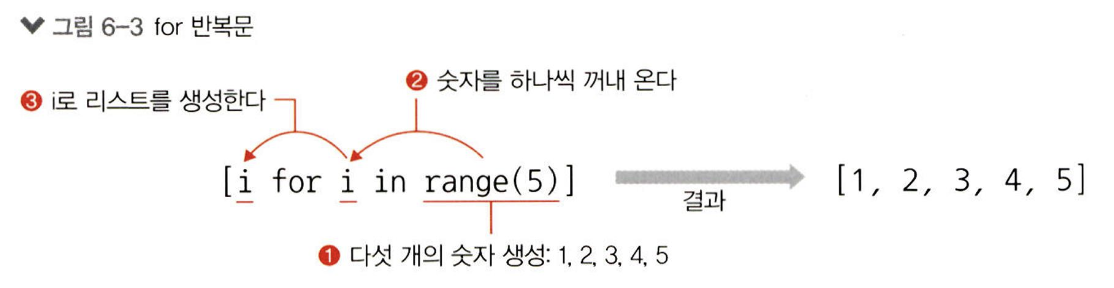
    - **for i in images_filepaths** : 조건문(if)를 의미. cv2.imread() 함수(cv2.imread(i))를 이용하여 모든 이미지 데이터를 읽어옴
      - non None 상태 : '더 이상 데이터를 찾을 수 없을 때까지'를 의미
---

- **random.seed(42)**
  - 넘파이 random() 함수는 임의의 난수를 생성. 이때 난수를 생성하기 위해 사용되는 것이 시드 값(seed value)
  - 또한, Numpy.random.seed()메서드는 상태를 초기화
  - 이 모듈이 호출될 때마다 임의의 난수가 재생성
  - 하지만, 특정 시드 값을 부여하면 상태가 저장되기 때문에 동일한 난수를 생성

## 4. 테스트 데이터셋 이미지 확인 함수

In [6]:
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):

    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))

    for i, image_filepath in enumerate(images_filepaths):

        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        true_label = os.path.normpath(image_filepath).split(os.sep)[-2]
        predicted_label = predicted_labels[i] if predicted_labels else true_label
        color = "green" if true_label == predicted_label else "red"

        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(predicted_label, color=color)
        ax.ravel()[i].set_axis_off()

    plt.tight_layout()
    plt.show()

## 5. 테스트 데이터셋 이미지를 출력

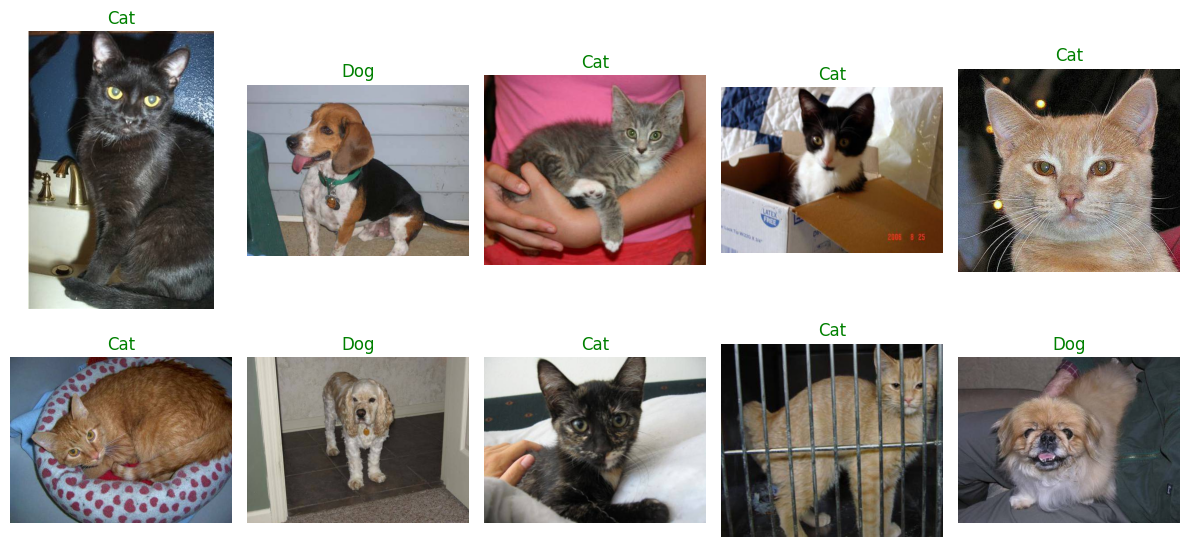

In [7]:
display_image_grid(test_images_filepaths)

- **데이터셋 준비 완료 후** 모델 학습을 위한 구체적인 단계가 시작됨.

- **Dataset 클래스의 역할**
  - 학습할 데이터의 **경로를 정의**함.
  - `__init__` 메서드에서는 전체 데이터를 **바로 불러오지 않고 경로만 저장**함.
  - **실제 이미지는 `__getitem__` 메서드**에서 불러옴 → 데이터가 어디에 있는지만 기억하고, 실제 로딩은 나중에 처리.

- **DataLoader의 역할**
  - Dataset에서 데이터를 불러와 **메모리에 올림**.
  - 한 번에 전체 데이터를 불러오는 것이 아니라, **배치 크기만큼 나누어 로드**함.

- **DogsVsCatDataset 클래스**
  - 개와 고양이 이미지가 섞인 데이터셋에서 **이미지가 개인지 고양이인지 예측**하는 것이 목적.
  - 따라서 **레이블(정답)을 직접 코드로 구현**해야 함.
    - 예시:
      - **고양이 이미지의 레이블 → 0**
      - **개 이미지의 레이블 → 1**

## 6. 이미지 데이터셋 클래스 정의

In [8]:
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

- **이미지 데이터에서 레이블 값(dog, cat)을 가져오는 코드**

  ```python
  label = img_path.split('/')[-1].split('.')[0]
  ```

- **코드 설명**

  - `@ img_path`:  
    - 이미지가 저장된 **전체 경로**를 의미함.   
      ```
      E:/torch/chap06/data/dogs-vs-cats/Dog/dog.113.jpg
      ```

  - `① img_path.split('/')[-1]`:  
    - 전체 경로에서 마지막 항목인 **'파일명'만 추출**함.  
      ```
      'dog.113.jpg'
      ```

  - `② .split('.')[0]`:  
    - 파일명을 `'.'` 기준으로 나눠서 **확장자(.jpg) 제거**  
    - `'dog.113.jpg' → ['dog', '113', 'jpg']`  
    - 인덱스 `[0]`을 통해 `'dog'` 추출

- **결과적으로 얻는 값**
  - `'dog.113.jpg'`에서 `'dog'`를 레이블로 추출하게 됨

## 7. 변수 값 정의

In [9]:
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

## 8. 이미지 데이터셋 정의

In [10]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 224, 224])
0


- **훈련 데이터의 크기와 레이블 출력 결과 예시**
  ```
  torch.Size([3, 224, 224])
  1
  ```

- **해석**
  - `torch.Size([3, 224, 224])`:  
    - 훈련 이미지의 크기를 의미함  
    - **컬러 이미지**이므로 채널 수 3 (RGB)  
    - 이미지 크기는 **224 × 224**

  - `1`:  
    - 해당 이미지의 **레이블(label)** 값  
    - 이 경우 `1`이므로, **"개(dog)" 이미지**임을 의미

- **추론 포인트**
  - `train_dataset.__getitem__(index)[1]`의 값이 1이라는 건, 해당 데이터가 **'개' 이미지**라는 것
  - 전처리(transform)와 함께 데이터셋이 정의되었기 때문에, 메모리로 불러와서 학습 준비가 완료된 상태

## 9. 데이터로더 정의

In [11]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
        0, 1, 1, 0, 1, 0, 0, 1])


- **DataLoader 사용 설명**

    ```python
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    ```

    - `① DataLoader`: 파이토치에서 **배치 단위로 데이터를 관리**해주는 클래스  
      - 데이터를 한 번에 모두 불러오지 않고, 메모리 부담을 줄이기 위해 **작게 나누어(batch) 불러옴**
---

- **파라미터 설명**
  - `a. 첫 번째 파라미터`:
    - **데이터셋 객체 (예: `train_dataset`)**
    - 어떤 데이터를 불러올지 지정

  - `b. batch_size`:
    - **한 번에 불러올 데이터 수**
    - 예: `batch_size=32` → 한 번에 32개씩 가져옴

  - `c. shuffle`:
    - **데이터를 불러올 때 섞을지 여부**
    - `True`이면 **매 epoch마다 데이터를 섞어서 불러옴**

---

- **출력 예시 (메모리에 불러온 후)**

  ```python
  torch.Size([32, 3, 224, 224])
  tensor([1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0])
  ```

  - `torch.Size([32, 3, 224, 224])`:  
    - 32개의 이미지가  
    - RGB 3채널,  
    - 크기 224×224로 불러와졌음을 의미

  - `tensor([...])`:  
    - 각각의 이미지에 해당하는 **레이블 값들**
    - 0: 고양이, 1: 개

## 10. 모델의 네트워크 클래스

In [12]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU() # activation
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(32*53*53, 512)
        self.relu5 = nn.ReLU()
        self.fc2 = nn.Linear(512, 2)
        self.output = nn.Softmax(dim=1)

    def forward(self, x):
        out = self.cnn1(x)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out = self.cnn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        out = self.output(out)
        return out

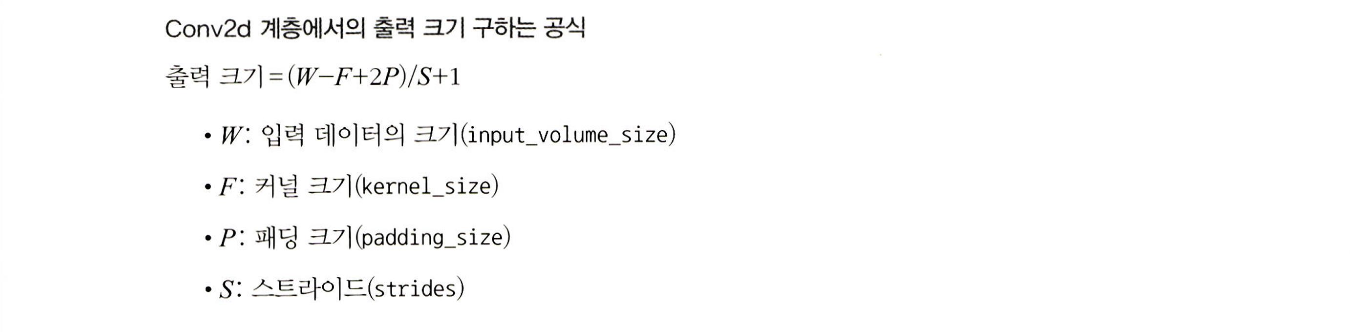

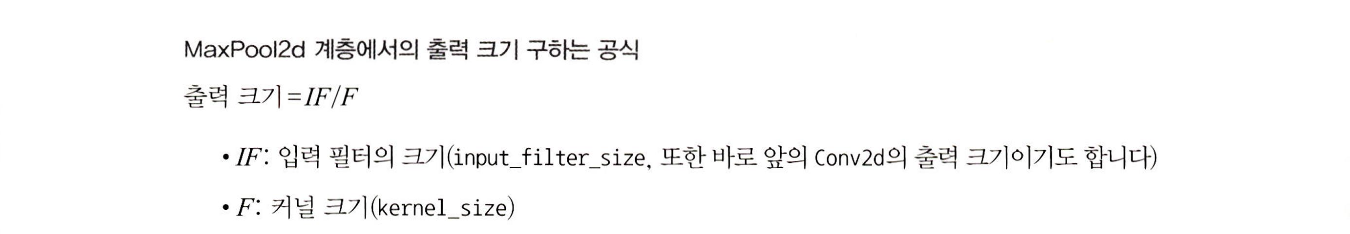

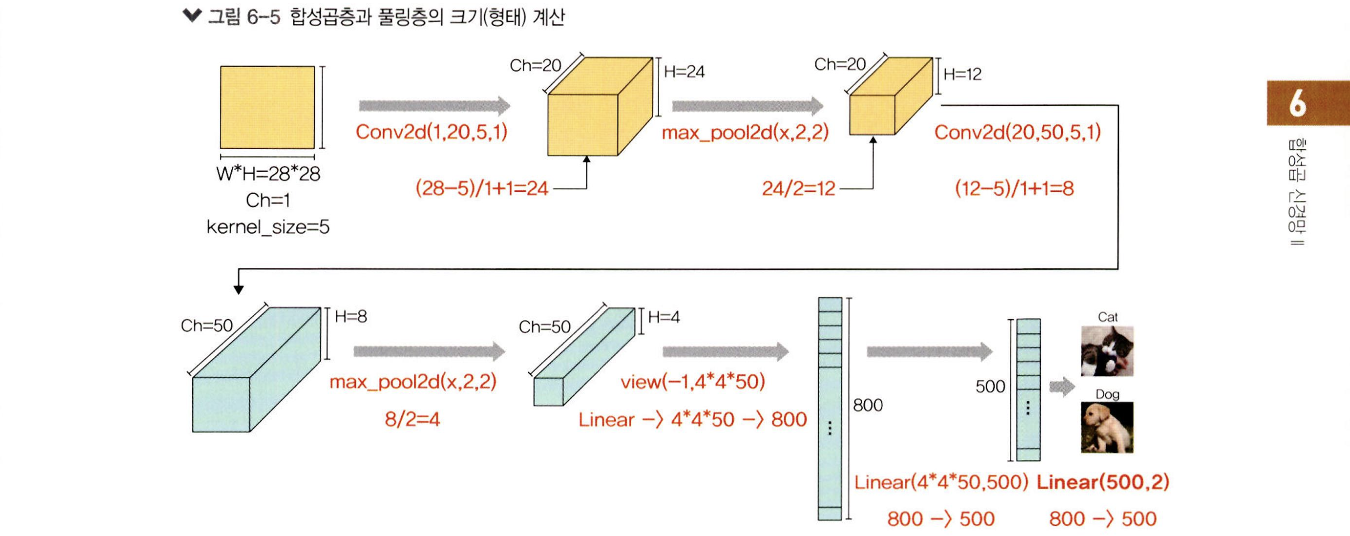

## 11. 모델 객체 생성

In [13]:
model = LeNet().to(device)
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


## 12. torchsummary 라이브러리를 이용한 모델의 네트워크 구조 확인

In [ ]:
!pip install torchsummary

In [ ]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

- `summary` 함수 사용법 (torchsummary)

  ```python
  summary(model, input_size=(3, 224, 224))
  ```

  - `① summary`를 통해 **모델의 네트워크 구조 및 파라미터 정보를 확인**할 수 있음

---
- 파라미터 설명

  - `a. 첫 번째 파라미터:`  
    - **모델 객체 (예: `model`)**
    - 분석할 **신경망 네트워크**

  - `b. 두 번째 파라미터:`  
    - **입력 이미지의 크기**  
    - `(채널 수, 너비, 높이)` 형식으로 지정  
    - 예: `(3, 224, 224)` → 3채널 컬러 이미지 (224 × 224 크기)

---
- 출력 결과에는 다음과 같은 정보 포함

  - 전체 **파라미터 수**
  - 각 층의 **입력/출력 크기**
  - 전체 **네트워크 크기**
  - 각 레이어별 연산 정보

## 13. 학습 가능한 파라미터 수 확인

In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 46,038,242 trainable parameters


## 14. 옵티마이저와 손실 함수 정의

In [15]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

- 옵티마이저 설정: 모멘텀 SGD 사용

  ```python
  optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
  ```

---
- 파라미터 설명
  - `a. model.parameters()`  
    - **업데이트할 대상 파라미터**  
    - 모델의 **가중치(weight)**와 **바이어스(bias)** 포함  
    - 예시 모델에서는 총 **46,038,242개** 파라미터 존재

  - `b. lr (learning rate)`  
    - 학습률  
    - **가중치를 얼마나 크게 조정할지**를 결정함  
    - 예: `0.001` → 조금씩 천천히 학습

  - `c. momentum`  
    - 모멘텀 계수 (진동 억제용)  
    - 이전 방향(속도)을 반영하여 **가속하면서 학습**,  
    - 진동이나 흔들림 줄임

---
- **모멘텀 SGD**는 기본 SGD에 **관성 개념을 더한 방식**  
  - 이전의 기울기 방향을 고려하여 같은 방향으로 더 안정적이고 빠르게 이동함

- PyTorch에서는 **GPU 자동 활성화되지 않음**  
  - 모델과 손실 함수 등을 GPU에 명시적으로 할당해야 함  
  - 현재는 **CPU 기반 학습 중**

## 15. 모델의 파라미터와 손실 함수를 CPU에 할당

In [16]:
model = model.to(device)
criterion = criterion.to(device)

## 16. 모델 학습 함수 정의

In [17]:
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch + 1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    epoch_loss += loss.item() * inputs.size(0)
                    epoch_corrects += torch.sum(preds == labels.data)

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    return model

## 17. 모델 학습

In [18]:
import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


<ipython-input-17-fa628574df2f>:18: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6973 Acc: 0.4825


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.7155 Acc: 0.4891
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6584 Acc: 0.6050


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.7032 Acc: 0.5000
Training complete in 5m 44s
Best val Acc: 0.565217


## 18. 모델 테스트를 위한 함수 정의

In [19]:
import pandas as pd

id_list = []
pred_list = []
_id=0
with torch.no_grad():
    for test_path in tqdm(test_images_filepaths):
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('LesNet.csv', index=False)

<ipython-input-19-22a78dd8e791>:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):


  0%|          | 0/10 [00:00<?, ?it/s]

## 19. 테스트 데이터셋의 예측 결과 호출

In [20]:
res.head(10)

,id,label
0,109,0.548381
1,145,0.476355
2,15,0.582687
3,162,0.570650
4,167,0.518530
5,200,0.493448
6,210,0.604339
7,211,0.617867
8,213,0.508810
9,224,0.539326


## 20. 테스트 데이터셋 이미지를 출력하기 위한 함수 정의

In [21]:
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        a = random.choice(res['id'].values)
        label = res.loc[res['id'] == a, 'label'].values[0]
        if label > 0.5:
            label = 1
        else:
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

## 21. 테스트 데이터셋 예측 결과 이미지 출력

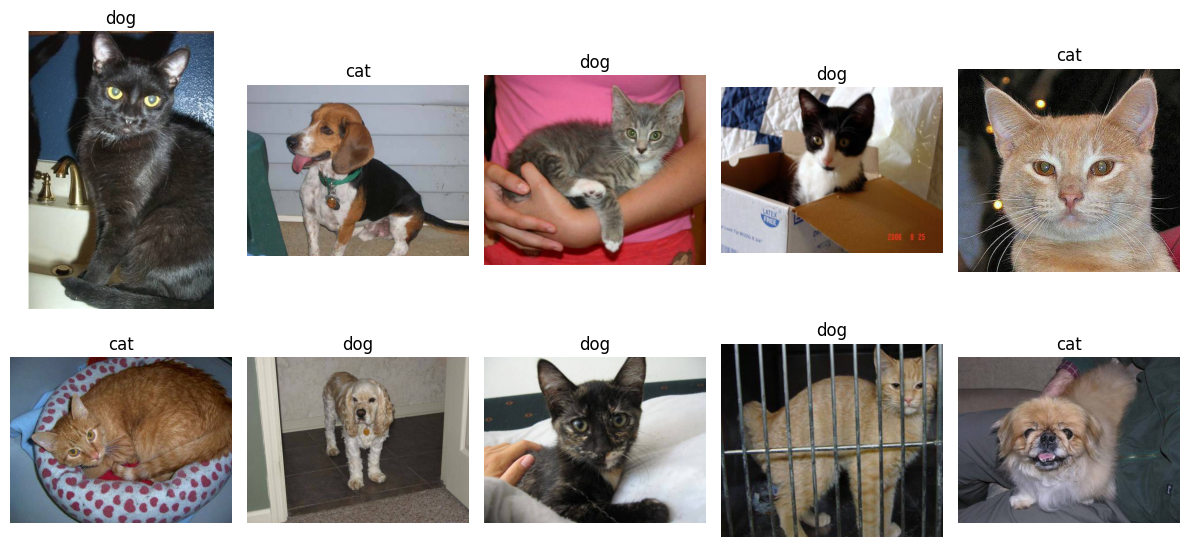

In [22]:
display_image_grid(test_images_filepaths)

- 예측력이 좋지는 않습니다.
  - 극히 일부의 데이터를 이용한 모델 학습을 진행했기 때문에 이와 같은
예측력을 보여 줍니다.
  - 앞에서 말했듯이 캐글에서 내려받은 데이터 전체를 사용한다면 성능이 높
아지겠지만 CPU를 사용한다면 훈련 시간은 며칠이 걸릴 수도 있습니다.